# Fase 2: búsqueda, recopilación e implementación de modelos de regresión

## California Housing — Grupo 05

Este notebook documenta el flujo técnico de la Fase 2 del proyecto de Machine Learning. Su propósito es preparar el conjunto California Housing, implementar tres modelos de regresión supervisada y compararlos mediante métricas calculadas sobre datos de prueba.


## Problema y objetivo analítico

El problema consiste en estimar el valor mediano de las viviendas de los distritos de California a partir de variables demográficas, habitacionales y geográficas.

El objetivo es implementar y comparar una regresión lineal, un árbol de decisión y una red neuronal MLP para determinar cuál presenta mejor desempeño predictivo sobre observaciones no utilizadas durante el entrenamiento.


## Enfoque metodológico

Se utiliza aprendizaje supervisado de regresión porque cada observación contiene variables predictoras y un valor conocido de `MedHouseVal`. Esta variable objetivo es numérica continua y está expresada en cientos de miles de dólares.

La regresión lineal se utiliza como línea base interpretable; el árbol permite representar relaciones no lineales mediante reglas; y el MLP permite aprender patrones más complejos. La comparación se realiza con MSE, RMSE y R².


## Alcance y decisiones de reproducibilidad

1. Carga y revisión del dataset California Housing.
2. Separación de predictores (`X`) y variable objetivo (`y`).
3. Partición 80 % entrenamiento y 20 % prueba con `random_state=42`.
4. Ajuste de `StandardScaler` exclusivamente con los datos de entrenamiento.
5. Entrenamiento de regresión lineal, árbol de decisión y MLP.
6. Evaluación sobre el conjunto de prueba mediante MSE, RMSE y R².
7. Comparación y selección preliminar del mejor modelo.

No se realiza ajuste exhaustivo de hiperparámetros ni validación cruzada; estas actividades quedan proyectadas para una etapa posterior.


### Dataset de Precios de Viviendas en California para Regresión

Este dataset contiene características demográficas y de vivienda para los distritos censales de California en 1990. Es ideal para tareas de regresión donde el objetivo es predecir el valor mediano de las casas.

**Características Clave:**
- `MedInc`: Ingreso mediano en el distrito (en decenas de miles de dólares).
- `HouseAge`: Edad media de las casas en el distrito.
- `AveRooms`: Número medio de habitaciones por vivienda.
- `AveBedrms`: Número medio de dormitorios por vivienda.
- `Population`: Población del distrito.
- `AveOccup`: Número medio de ocupantes por hogar.
- `Latitude`: Latitud del distrito.
- `Longitude`: Longitud del distrito.
- **Target (`MedHouseVal`)**: Valor mediano de las casas en el distrito (en cientos de miles de dólares).

Este dataset es conocido por no tener valores faltantes en su forma estándar, lo que lo hace perfecto para comenzar.

In [1]:
import pandas as pd
from sklearn.datasets import fetch_california_housing

try:
    housing = fetch_california_housing(as_frame=True)
    df = housing.frame.copy()
    fuente_datos = "scikit-learn: fetch_california_housing"
except Exception as error_descarga:
    # Respaldo reproducible cuando el servidor oficial rechaza temporalmente la descarga.
    url_respaldo = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv"
    raw = pd.read_csv(url_respaldo)
    # La copia pública conserva las variables censales originales. Se derivan las
    # mismas ocho características utilizadas por la versión de scikit-learn.
    raw["total_bedrooms"] = raw["total_bedrooms"].fillna(raw["total_bedrooms"].median())
    df = pd.DataFrame({
        "MedInc": raw["median_income"],
        "HouseAge": raw["housing_median_age"],
        "AveRooms": raw["total_rooms"] / raw["households"],
        "AveBedrms": raw["total_bedrooms"] / raw["households"],
        "Population": raw["population"],
        "AveOccup": raw["population"] / raw["households"],
        "Latitude": raw["latitude"],
        "Longitude": raw["longitude"],
        "MedHouseVal": raw["median_house_value"] / 100000
    })
    fuente_datos = "copia pública de respaldo del censo de California"
    print(f"Aviso: no fue posible acceder al servidor oficial ({type(error_descarga).__name__}).")

print("Fuente utilizada:", fuente_datos)
print("Dimensiones del dataset:", df.shape)
print("Primeras 5 filas del dataset:")
display(df.head())
print("\nRecuento de valores nulos por columna:")
display(df.isnull().sum())


C:\Users\Bass\Desktop\U\MachineLearning1\.venv\Lib\site-packages\sklearn\datasets\_base.py:1522: UserWarning: Retry downloading from url: https://ndownloader.figshare.com/files/5976036
  warnings.warn(f"Retry downloading from url: {remote.url}")


Fuente utilizada: scikit-learn: fetch_california_housing
Dimensiones del dataset: (20640, 9)
Primeras 5 filas del dataset:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422



Recuento de valores nulos por columna:


MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

## 1. Preparación de Datos para Modelos de Machine Learning

Antes de entrenar cualquier modelo de Machine Learning, es crucial preparar los datos adecuadamente. Esto incluye:

*   **Separar características (X) y variable objetivo (y):** Las características son las variables de entrada que el modelo usará para hacer predicciones, y la variable objetivo es lo que queremos predecir.
*   **Dividir el dataset en conjuntos de entrenamiento y prueba:** Esto nos permite entrenar el modelo con una parte de los datos y evaluar su rendimiento con datos que nunca ha visto, para tener una estimación realista de su capacidad de generalización.
*   **Escalar las características:** Algunos algoritmos de Machine Learning (como las redes neuronales y la regresión lineal si se usa regularización) se benefician de tener las características en una escala similar. Esto evita que una característica con un rango de valores más grande domine el cálculo de distancias o gradientes.

In [2]:
from sklearn.model_selection import train_test_split  # Importa la función para dividir el dataset en conjuntos de entrenamiento y prueba.
from sklearn.preprocessing import StandardScaler  # Importa StandardScaler para escalar (estandarizar) las características.

# --- Explicación de las variables del dataset ---
# Las columnas de nuestro DataFrame 'df' son:
# 'MedInc': Ingreso mediano en el distrito (en decenas de miles de dólares).
# 'HouseAge': Edad media de las casas en el distrito.
# 'AveRooms': Número medio de habitaciones por vivienda.
# 'AveBedrms': Número medio de dormitorios por vivienda.
# 'Population': Población del distrito.
# 'AveOccup': Número medio de ocupantes por hogar.
# 'Latitude': Latitud del distrito.
# 'Longitude': Longitud del distrito.
# 'MedHouseVal': Valor mediano de las casas en el distrito (en cientos de miles de dólares). Esta es nuestra variable objetivo.

# 1. Separar características (X) y variable objetivo (y)
# X contendrá todas las columnas excepto 'MedHouseVal'.
X = df.drop('MedHouseVal', axis=1)  # Crea X (features) eliminando la columna 'MedHouseVal'. 'axis=1' indica que es una columna.
# y contendrá únicamente la columna 'MedHouseVal'.
y = df['MedHouseVal']  # Crea y (target) seleccionando solo la columna 'MedHouseVal'.

print(f"Dimensiones de X (características): {X.shape}")  # Muestra las dimensiones del DataFrame de características.
print(f"Dimensiones de y (variable objetivo): {y.shape}")  # Muestra las dimensiones de la Serie de la variable objetivo.

# 2. Dividir el dataset en conjuntos de entrenamiento y prueba
# Usamos train_test_split para dividir X e y.
# test_size=0.20 significa que el 20% de los datos se usarán para prueba y el 80% para entrenamiento.
# random_state=42 asegura que la división sea reproducible (siempre obtendremos los mismos conjuntos).
# X_train, y_train son para entrenar el modelo.
# X_test, y_test son para evaluar el modelo.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)  # Realiza la división de los datos.

print(f"Dimensiones de X_train: {X_train.shape}")  # Muestra las dimensiones del conjunto de características de entrenamiento.
print(f"Dimensiones de X_test: {X_test.shape}")    # Muestra las dimensiones del conjunto de características de prueba.
print(f"Dimensiones de y_train: {y_train.shape}")  # Muestra las dimensiones del conjunto de la variable objetivo de entrenamiento.
print(f"Dimensiones de y_test: {y_test.shape}")    # Muestra las dimensiones del conjunto de la variable objetivo de prueba.

# 3. Escalar las características
# Inicializamos el escalador StandardScaler. Este transformará los datos para que tengan una media de 0 y una desviación estándar de 1.
scaler = StandardScaler()  # Inicializa un objeto StandardScaler.

# Ajustamos el escalador solo con los datos de entrenamiento (X_train).
# Es importante no 'filtrar' información del conjunto de prueba al ajustar el escalador.
scaler.fit(X_train)  # Calcula la media y la desviación estándar de cada característica en X_train.

# Transformamos tanto los datos de entrenamiento como los de prueba usando el escalador ajustado.
# X_train_scaled y X_test_scaled contendrán las características escaladas.
X_train_scaled = scaler.transform(X_train)  # Aplica la transformación de escalado a X_train.
X_test_scaled = scaler.transform(X_test)    # Aplica la transformación de escalado a X_test.

print("\nPrimeras 5 filas de X_train (escalado):\n")  # Imprime un mensaje indicando que se mostrarán los datos escalados.
display(pd.DataFrame(X_train_scaled, columns=X.columns).head())  # Convierte la matriz NumPy escalada a DataFrame para mostrar las primeras 5 filas.

Dimensiones de X (características): (20640, 8)
Dimensiones de y (variable objetivo): (20640,)
Dimensiones de X_train: (16512, 8)
Dimensiones de X_test: (4128, 8)
Dimensiones de y_train: (16512,)
Dimensiones de y_test: (4128,)

Primeras 5 filas de X_train (escalado):



,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,-0.326196,0.348490,-0.174916,-0.208365,0.768276,0.051376,-1.372811,1.272587
1,-0.035843,1.618118,-0.402835,-0.128530,-0.098901,-0.117362,-0.876696,0.709162
2,0.144701,-1.952710,0.088216,-0.257538,-0.449818,-0.032280,-0.460146,-0.447603
3,-1.017864,0.586545,-0.600015,-0.145156,-0.007434,0.077507,-1.382172,1.232698
4,-0.171488,1.142008,0.349007,0.086624,-0.485877,-0.068832,0.532084,-0.108551


## 2. Regresión Lineal

### 2.1. Concepto de Regresión Lineal

La Regresión Lineal es uno de los algoritmos de Machine Learning más fundamentales y ampliamente utilizados para predecir un valor continuo (numérico). Asume una relación lineal entre las características de entrada (X) y la variable objetivo (y). En su forma más simple, busca encontrar la línea recta (o un hiperplano en múltiples dimensiones) que mejor se ajusta a los datos, minimizando la suma de los errores cuadrados entre los valores predichos y los valores reales.

La ecuación general de un modelo de regresión lineal simple es:

$y = \beta_0 + \beta_1x_1 + \beta_2x_2 + ... + \beta_nx_n + \epsilon$

Donde:
*   $y$: Variable objetivo (lo que queremos predecir).
*   $x_i$: Las características de entrada.
*   $\beta_0$: El intercepto (el valor de y cuando todas las $x_i$ son cero).
*   $\beta_i$: Los coeficientes de regresión para cada característica $x_i$, que representan cuánto cambia $y$ por cada unidad de cambio en $x_i$, manteniendo las demás características constantes.
*   $\epsilon$: El término de error, que representa la variabilidad no explicada por el modelo.

### 2.2. Implementación de Regresión Lineal

In [3]:
from sklearn.linear_model import LinearRegression  # Importa el modelo de Regresión Lineal de scikit-learn.
from sklearn.metrics import mean_squared_error, r2_score  # Importa las métricas de evaluación MSE y R^2.
import numpy as np  # Importa la librería NumPy para operaciones numéricas, aunque no se usa directamente en este bloque, es una importación común.

# 1. Inicializar el modelo de Regresión Lineal
# Creamos una instancia del modelo LinearRegression de scikit-learn.
linear_model = LinearRegression()  # Crea una instancia del modelo de Regresión Lineal.

# 2. Entrenar el modelo
# El método .fit() entrena el modelo usando los datos de entrenamiento escalados (X_train_scaled) y las etiquetas de entrenamiento (y_train).
# El modelo aprende los coeficientes (betas) que mejor describen la relación lineal.
linear_model.fit(X_train_scaled, y_train)  # Entrena el modelo con las características escaladas y la variable objetivo de entrenamiento.

print("Modelo de Regresión Lineal entrenado.")  # Confirma que el modelo ha sido entrenado.

# 3. Realizar predicciones en el conjunto de prueba
# Una vez entrenado, usamos el método .predict() para generar predicciones sobre el conjunto de prueba escalado (X_test_scaled).
# Estas predicciones, y_pred_linear, son los valores de MedHouseVal que el modelo estima para los datos de prueba.
y_pred_linear = linear_model.predict(X_test_scaled)  # Genera predicciones sobre el conjunto de prueba escalado.

print("\nPrimeras 5 predicciones del modelo de Regresión Lineal:")  # Imprime un mensaje indicando las predicciones.
display(y_pred_linear[:5])  # Muestra las primeras 5 predicciones realizadas por el modelo.

# 4. Evaluar el modelo
# Calculamos el Error Cuadrático Medio (MSE) y el coeficiente de determinación (R^2).
# MSE: Mide el promedio de los errores al cuadrado. Un valor más bajo indica un mejor ajuste.
mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)  # Calcula el Error Cuadrático Medio comparando los valores reales (y_test) y las predicciones (y_pred_linear).
# R^2: Representa la proporción de la varianza en la variable dependiente que es predecible a partir de las variables independientes.
# Un valor de 1.0 indica un ajuste perfecto, mientras que 0.0 indica que el modelo no explica la variabilidad.
r2_linear = r2_score(y_test, y_pred_linear)  # Calcula el coeficiente R^2 para el modelo.

print(f"\n--- Evaluación del Modelo de Regresión Lineal ---")  # Imprime un encabezado para la sección de evaluación.
print(f"Error Cuadrático Medio (MSE): {mse_linear:.4f}")  # Muestra el valor del MSE formateado a 4 decimales.
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse_linear:.4f}")
print(f"Coeficiente de Determinación (R^2): {r2_linear:.4f}")  # Muestra el valor del R^2 formateado a 4 decimales.


Modelo de Regresión Lineal entrenado.

Primeras 5 predicciones del modelo de Regresión Lineal:


array([0.71912284, 1.76401657, 2.70965883, 2.83892593, 2.60465725])


--- Evaluación del Modelo de Regresión Lineal ---
Error Cuadrático Medio (MSE): 0.5559
Raíz del Error Cuadrático Medio (RMSE): 0.7456
Coeficiente de Determinación (R^2): 0.5758


### 2.3 Interpretación de la regresión lineal

La regresión lineal funciona como línea base por su simplicidad e interpretabilidad. El MSE penaliza con mayor intensidad los errores grandes; el RMSE expresa el error típico en la misma unidad de `MedHouseVal`; y R² indica la proporción de variabilidad explicada. La interpretación cuantitativa se realizará usando los valores obtenidos en la ejecución, no valores hipotéticos.

Como los predictores fueron estandarizados, los coeficientes permiten comparar dirección e intensidad relativa, aunque no deben interpretarse como cambios en las unidades originales.


## 3. Árboles de Decisión para Regresión

### 3.1. Concepto de Árbol de Decisión

Los Árboles de Decisión para Regresión son algoritmos no paramétricos que dividen el espacio de las características en regiones más pequeñas y hacen una predicción (el valor promedio de la variable objetivo) para cada región. Son intuitivos, fáciles de interpretar y pueden capturar relaciones no lineales en los datos. Cada "nodo" en el árbol representa una decisión basada en una característica, y las "hojas" del árbol contienen la predicción final.

### 3.2. Implementación de Árbol de Decisión

In [4]:
from sklearn.tree import DecisionTreeRegressor  # Importa el modelo de Árbol de Decisión para regresión.
from sklearn.metrics import mean_squared_error, r2_score  # Importa las métricas de evaluación MSE y R^2.

# 1. Inicializar el modelo de Árbol de Decisión para Regresión
# max_depth es un hiperparámetro importante que controla la profundidad máxima del árbol.
# Limitar la profundidad ayuda a prevenir el sobreajuste (overfitting).
# random_state asegura la reproducibilidad de los resultados.
decision_tree_model = DecisionTreeRegressor(max_depth=5, random_state=42)  # Crea una instancia del modelo, limitando la profundidad a 5 y fijando la semilla aleatoria.

# 2. Entrenar el modelo
# Entrenamos el modelo con los datos escalados de entrenamiento.
decision_tree_model.fit(X_train_scaled, y_train)  # Entrena el modelo de Árbol de Decisión con los datos de entrenamiento escalados.

print("Modelo de Árbol de Decisión entrenado.")  # Confirma que el modelo ha sido entrenado.

# 3. Realizar predicciones en el conjunto de prueba
y_pred_tree = decision_tree_model.predict(X_test_scaled)  # Genera predicciones sobre el conjunto de prueba escalado.

print("\nPrimeras 5 predicciones del modelo de Árbol de Decisión:")  # Imprime un mensaje indicando las predicciones.
display(y_pred_tree[:5])  # Muestra las primeras 5 predicciones del modelo.

# 4. Evaluar el modelo
mse_tree = mean_squared_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mse_tree)  # Calcula el Error Cuadrático Medio para el modelo de Árbol de Decisión.
r2_tree = r2_score(y_test, y_pred_tree)  # Calcula el coeficiente R^2 para el modelo de Árbol de Decisión.

print(f"\n--- Evaluación del Modelo de Árbol de Decisión ---")  # Imprime un encabezado para la sección de evaluación.
print(f"Error Cuadrático Medio (MSE): {mse_tree:.4f}")  # Muestra el valor del MSE formateado.
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse_tree:.4f}")
print(f"Coeficiente de Determinación (R^2): {r2_tree:.4f}")  # Muestra el valor del R^2 formateado.


Modelo de Árbol de Decisión entrenado.

Primeras 5 predicciones del modelo de Árbol de Decisión:


array([1.16857267, 1.27158128, 3.19958174, 2.20476301, 1.64279735])


--- Evaluación del Modelo de Árbol de Decisión ---
Error Cuadrático Medio (MSE): 0.5245
Raíz del Error Cuadrático Medio (RMSE): 0.7242
Coeficiente de Determinación (R^2): 0.5997


### 3.3 Interpretación del árbol de decisión

El árbol puede capturar umbrales, interacciones y relaciones no lineales. Se fija `max_depth=5` para limitar su complejidad y reducir el riesgo de sobreajuste, mientras que `random_state=42` asegura reproducibilidad. Aunque el árbol no requiere escalamiento, se conserva la misma representación de entrada para mantener un pipeline comparable entre modelos.


## 4. Redes Neuronales (Perceptrón Multicapa - MLP)

### 4.1. Concepto de Red Neuronal para Regresión

Las Redes Neuronales Artificiales, particularmente el Perceptrón Multicapa (MLP), son modelos inspirados en la estructura del cerebro humano. Consisten en capas de "neuronas" interconectadas que procesan información. Para tareas de regresión, la capa de salida típicamente tiene una única neurona sin función de activación (o una función lineal) que produce un valor continuo.

Las redes neuronales son excelentes para capturar relaciones complejas y no lineales en los datos, a menudo superando a los modelos más simples cuando se dispone de suficientes datos y recursos computacionales.

### 4.2. Implementación de Red Neuronal

In [5]:
from sklearn.neural_network import MLPRegressor  # Importa el Perceptrón Multicapa para regresión (Red Neuronal).
from sklearn.metrics import mean_squared_error, r2_score  # Importa las métricas de evaluación MSE y R^2.

# 1. Inicializar el modelo de Red Neuronal (MLPRegressor)
# hidden_layer_sizes: Define la arquitectura de la red (número de neuronas por capa oculta).
#    Ahora usaremos una sola capa oculta con 100 neuronas.
# activation: Función de activación para las capas ocultas (por ejemplo, 'relu' para Rectified Linear Unit).
# solver: Algoritmo de optimización para el aprendizaje ('adam' es una opción común y eficiente).
# max_iter: Número máximo de iteraciones (epochs) para el entrenamiento.
# random_state: Para reproducibilidad.
# early_stopping: Detiene el entrenamiento si el rendimiento en el conjunto de validación no mejora, para evitar sobreajuste.
mlp_model = MLPRegressor(hidden_layer_sizes=(100,), activation='relu', solver='adam',
                         max_iter=500, random_state=42, early_stopping=True)  # Crea una instancia del modelo MLPRegressor con una capa oculta de 100 neuronas.

# 2. Entrenar el modelo
# Las redes neuronales son sensibles a la escala de los datos, por lo que usar X_train_scaled es crucial.
mlp_model.fit(X_train_scaled, y_train)  # Entrena la red neuronal con los datos escalados de entrenamiento.

print("Modelo de Red Neuronal (MLP) entrenado.")  # Confirma que el modelo ha sido entrenado.

# 3. Realizar predicciones en el conjunto de prueba
y_pred_mlp = mlp_model.predict(X_test_scaled)  # Genera predicciones sobre el conjunto de prueba escalado.

print("\nPrimeras 5 predicciones del modelo de Red Neuronal:")  # Imprime un mensaje indicando las predicciones.
display(y_pred_mlp[:5])  # Muestra las primeras 5 predicciones del modelo.

# 4. Evaluar el modelo
mse_mlp = mean_squared_error(y_test, y_pred_mlp)
rmse_mlp = np.sqrt(mse_mlp)  # Calcula el Error Cuadrático Medio para la red neuronal.
r2_mlp = r2_score(y_test, y_pred_mlp)  # Calcula el coeficiente R^2 para la red neuronal.

print(f"\n--- Evaluación del Modelo de Red Neuronal (MLP) ---")  # Imprime un encabezado para la sección de evaluación.
print(f"Error Cuadrático Medio (MSE): {mse_mlp:.4f}")  # Muestra el valor del MSE formateado.
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse_mlp:.4f}")
print(f"Coeficiente de Determinación (R^2): {r2_mlp:.4f}")  # Muestra el valor del R^2 formateado.


Modelo de Red Neuronal (MLP) entrenado.

Primeras 5 predicciones del modelo de Red Neuronal:


array([0.37468951, 1.17480468, 4.7541446 , 2.54774117, 2.91686581])


--- Evaluación del Modelo de Red Neuronal (MLP) ---
Error Cuadrático Medio (MSE): 0.3017
Raíz del Error Cuadrático Medio (RMSE): 0.5493
Coeficiente de Determinación (R^2): 0.7697


### 4.3 Interpretación de la red neuronal MLP

El MLP emplea una capa oculta de 100 neuronas, activación ReLU, optimizador Adam y un máximo de 500 iteraciones. `early_stopping=True` reserva internamente una fracción del entrenamiento para detener el ajuste cuando deja de mejorar, reduciendo el riesgo de sobreajuste. El escalamiento es especialmente importante para la estabilidad de la optimización.

Su principal ventaja es la capacidad para representar relaciones complejas; su principal limitación es una menor interpretabilidad frente a la regresión lineal y al árbol.


## 5. Comparación de Modelos de Regresión

Para determinar cuál modelo ha tenido el mejor rendimiento, podemos comparar sus métricas clave (MSE y R^2). Un modelo ideal tendrá un MSE bajo y un R^2 cercano a 1.0.

Comparación de modelos en el conjunto de prueba:


,Modelo,MSE,RMSE,R2
0,Red Neuronal (MLP),0.301732,0.549301,0.769742
1,Árbol de Decisión,0.524515,0.724234,0.599732
2,Regresión Lineal,0.555892,0.745581,0.575788


Modelo seleccionado preliminarmente: Red Neuronal (MLP)
Criterio principal: menor RMSE (0.549301).
Evidencia complementaria: MSE=0.301732 y R²=0.769742.


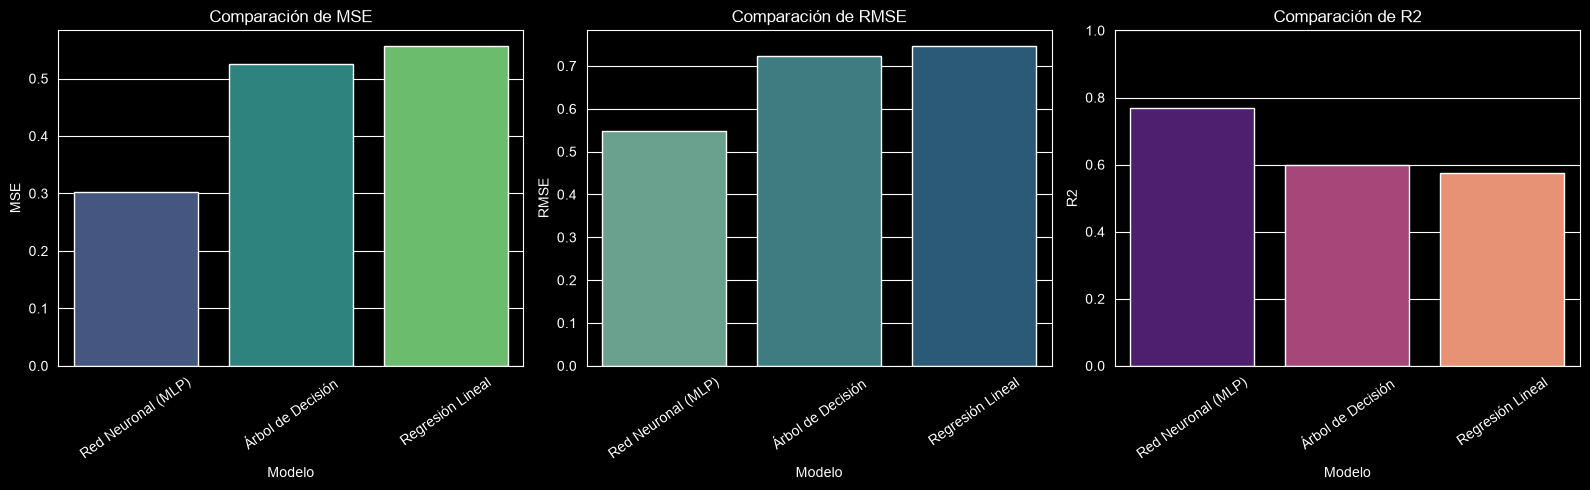

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

results = pd.DataFrame({
    "Modelo": ["Regresión Lineal", "Árbol de Decisión", "Red Neuronal (MLP)"],
    "MSE": [mse_linear, mse_tree, mse_mlp],
    "RMSE": [rmse_linear, rmse_tree, rmse_mlp],
    "R2": [r2_linear, r2_tree, r2_mlp]
}).sort_values("RMSE").reset_index(drop=True)

print("Comparación de modelos en el conjunto de prueba:")
display(results.style.format({"MSE":"{:.6f}", "RMSE":"{:.6f}", "R2":"{:.6f}"}))

mejor_modelo = results.iloc[0]
print(f"Modelo seleccionado preliminarmente: {mejor_modelo['Modelo']}")
print(f"Criterio principal: menor RMSE ({mejor_modelo['RMSE']:.6f}).")
print(f"Evidencia complementaria: MSE={mejor_modelo['MSE']:.6f} y R²={mejor_modelo['R2']:.6f}.")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric, palette in zip(axes, ["MSE", "RMSE", "R2"], ["viridis", "crest", "magma"]):
    sns.barplot(ax=ax, data=results, x="Modelo", y=metric, hue="Modelo", palette=palette, legend=False)
    ax.set_title(f"Comparación de {metric}")
    ax.tick_params(axis="x", rotation=35)
    if metric == "R2": ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


### 5.1 Criterio de comparación y selección

El modelo se selecciona principalmente por el menor RMSE, porque esta métrica representa el error típico en la misma escala de la variable objetivo. El MSE se utiliza como medida complementaria sensible a errores grandes y R² permite comparar la proporción de variabilidad explicada.

La elección es preliminar y se limita a la partición de prueba utilizada. Una conclusión definitiva requeriría validación cruzada, ajuste sistemático de hiperparámetros y análisis de residuos. También debe considerarse el equilibrio entre desempeño e interpretabilidad.


## 6. Documentación del proceso y trazabilidad

El notebook conserva en un mismo flujo la carga de datos, el preprocesamiento, los modelos y sus métricas. La partición reproducible, el ajuste del escalador solo con entrenamiento y el uso de semillas aleatorias permiten reconstruir las decisiones técnicas. Las tablas y gráficos generados constituyen la evidencia que debe trasladarse al informe y al repositorio.


In [7]:
resumen_trazabilidad = pd.DataFrame({
    "Etapa": ["Datos", "Partición", "Escalamiento", "Modelamiento", "Evaluación"],
    "Decisión": [
        "California Housing con MedHouseVal como objetivo continuo",
        "80 % entrenamiento y 20 % prueba; random_state=42",
        "StandardScaler ajustado exclusivamente con X_train",
        "Regresión lineal, árbol max_depth=5 y MLP (100,) con early stopping",
        "MSE, RMSE y R² calculados sobre el conjunto de prueba"
    ]
})
display(resumen_trazabilidad)


,Etapa,Decisión
0,Datos,California Housing con MedHouseVal como objeti...
1,Partición,80 % entrenamiento y 20 % prueba; random_state=42
2,Escalamiento,StandardScaler ajustado exclusivamente con X_t...
3,Modelamiento,"Regresión lineal, árbol max_depth=5 y MLP (100..."
4,Evaluación,"MSE, RMSE y R² calculados sobre el conjunto de..."


## 7. Síntesis

Los tres modelos se entrenan bajo una partición común y se evalúan sobre las mismas observaciones de prueba. La selección final se basa en los resultados efectivamente calculados, evitando afirmar superioridad antes de ejecutar el flujo. Las limitaciones identificadas orientan el trabajo posterior hacia validación cruzada, ajuste de hiperparámetros y análisis más detallado de los errores.
